In [1]:
import brainsss
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
#from sklearn.cluster import AgglomerativeClustering
import scipy
import time
import h5py
import ants
import nibabel as nib
from scipy.ndimage import uniform_filter, gaussian_filter,zoom
import shutil
from sklearn.cluster import AgglomerativeClustering
from sklearn.feature_extraction.image import grid_to_graph
import gc
import sys
import warnings
from scipy.ndimage import gaussian_filter1d,gaussian_filter
from scipy.signal import butter, sosfiltfilt, filtfilt, freqz,iirnotch
import cv2
from scipy.ndimage.morphology import binary_erosion,binary_dilation
from scipy.stats import norm
from sklearn.mixture import GaussianMixture
import pickle
import warnings

/home/users/ilanazs/.local/lib/python3.6/site-packages/ants/viz/render_surface_function.py:16: UserWarning:

Cant import Plotly. Install it `pip install chart_studio` if you want to use ants.render_surface_function



In [2]:
def supervoxel_to_full_res(brain, cluster_labels):
    n_clusters = brain.shape[2]
    n_tp = brain.shape[1]
    brain_dims=[314,146]
    
    reformed_brain = []
    for z in range(brain.shape[0]):
        colored_by_betas = np.zeros((n_tp, brain_dims[0]*brain_dims[1]))
        for cluster_num in range(n_clusters):
            cluster_mask = cluster_labels[z,:]==cluster_num
#             print(cluster_indicies)
            colored_by_betas[:,cluster_mask] = brain[z,:,cluster_num,np.newaxis]
        colored_by_betas = colored_by_betas.reshape(n_tp,brain_dims[0],brain_dims[1])
        reformed_brain.append(colored_by_betas)
    return np.asarray(reformed_brain)
def dual_channel_remove_noise(arr_r, arr_g):
    z,xy,t=np.shape(arr_g)
    flat_red=arr_r.reshape(xy*z,t)
    flat_green=arr_g.reshape(xy*z,t)
    print(flat_green.shape)
    flat_sig=np.zeros_like(flat_green)
    for i in range(np.shape(flat_red)[0]):
        a=np.polyfit(flat_red[i,:],flat_green[i,:],1)
#         print(np.shape(a))
        sig = flat_green[i,:] - (a[0]*flat_red[i,:] + a[1])
        flat_sig[i,:]=sig
    return flat_sig.reshape(z,xy,t)
def make_multi_behave_dict(behaviors,later_dir,step_size,event,ch_num):
    behave_dict = {}
    for behavior in behaviors:
        behave_dir = os.path.join(later_dir, behavior)
        behave_dict[behavior]=[]
        for file in os.listdir(behave_dir):
            if 'STA' in file and str(step_size) in file and event in file and f'_{ch_num}_' in file:
                STA_path=os.path.join(behave_dir, file)
                with h5py.File(STA_path, 'r') as sf:
                    brain = sf['data'][:]
                    brain[np.isnan(brain)] = 0
                    brain[np.isinf(brain)] = 4
                    brain = np.moveaxis(brain, 0, -1)
                    dims=np.shape(brain)
                    print(f'brain {file} shape: {dims}')
                    behave_dict[behavior]=brain
    return behave_dict

def make_supervox_dict(behave_dict, behaviors, n_clusters,cluster_labels):
    supervox_dict={}
    for behave in behaviors:
        supervox_dict[behave]=[]
        brain = behave_dict[behave]
        dims = np.shape(brain)
        for z in range(dims[-2]):
            neural_activity = brain[:,:,z,:].reshape(-1, dims[3])
            signals = []
            for cluster_num in range(n_clusters):
                cluster_indicies = np.where(cluster_labels[z,:]==cluster_num)[0]
                mean_signal = np.mean(neural_activity[cluster_indicies,:], axis=0)
                signals.append(mean_signal)
            signals = np.asarray(signals)
            supervox_dict[behave].append(signals)
        supervox_dict[behave] = np.asarray(supervox_dict[behave])
        print(f'{behave} shape: {np.shape(supervox_dict[behave])}')
    return supervox_dict

In [3]:
### big STA supervox
later_dir = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter'
cluster_dir = os.path.join(later_dir, 'clustering')
save_dir=os.path.join(later_dir,'figs')

behaviors = ['total', 'inc', 'dec', 'flat']

n_clusters=2000

step_size=100
event='10flies'
ch_g=2
ch_r=1
warnings.filterwarnings("ignore", category=RuntimeWarning)

# Load STAs for each behavior and channel

In [4]:
behave_dict_g = make_multi_behave_dict(behaviors,later_dir,step_size,event,ch_g)
behave_dict_r = make_multi_behave_dict(behaviors,later_dir,step_size,event,ch_r)

brain STA_2_total_100_10flies.h5 shape: (314, 146, 91, 24)
brain STA_2_inc_100_10flies.h5 shape: (314, 146, 91, 24)
brain STA_2_dec_100_10flies.h5 shape: (314, 146, 91, 24)
brain STA_2_flat_100_10flies.h5 shape: (314, 146, 91, 24)
brain STA_1_total_100_10flies.h5 shape: (314, 146, 91, 24)
brain STA_1_inc_100_10flies.h5 shape: (314, 146, 91, 24)
brain STA_1_dec_100_10flies.h5 shape: (314, 146, 91, 24)
brain STA_1_flat_100_10flies.h5 shape: (314, 146, 91, 24)


In [5]:
behave_dict_g.keys()

dict_keys(['total', 'inc', 'dec', 'flat'])

In [6]:
giant_cluster_labels = np.load(os.path.join(cluster_dir, 'cluster_labels_best_flies.npy'))

# Turn both channel STA dicts into Supervoxels

In [7]:
%%time
supervox_dict_g=make_supervox_dict(behave_dict_g, behaviors, n_clusters,giant_cluster_labels)
supervox_dict_r=make_supervox_dict(behave_dict_r, behaviors, n_clusters,giant_cluster_labels)

total shape: (91, 2000, 24)
inc shape: (91, 2000, 24)
dec shape: (91, 2000, 24)
flat shape: (91, 2000, 24)
total shape: (91, 2000, 24)
inc shape: (91, 2000, 24)
dec shape: (91, 2000, 24)
flat shape: (91, 2000, 24)
CPU times: user 48.5 s, sys: 130 ms, total: 48.7 s
Wall time: 48.7 s


# Remove noise using red channel regression

In [8]:
%%time
supervox_dict_total={}
for behave in behaviors:
#     print(behave)
    arr_g=supervox_dict_g[behave]
    arr_r=supervox_dict_r[behave]
    total_behave=dual_channel_remove_noise(arr_r, arr_g)
    supervox_dict_total[behave]=total_behave

(182000, 24)
(182000, 24)
(182000, 24)
(182000, 24)
CPU times: user 53.2 s, sys: 1.21 s, total: 54.4 s
Wall time: 51.6 s


In [9]:
top=supervox_dict_total['total'][:77].reshape(-1,24)
print(np.shape(top))
bottom=supervox_dict_total['total'][78:].reshape(-1,24)
print(np.shape(bottom))
concat=np.vstack([top,bottom])
print(np.shape(concat))
supervox_total_clean=np.asarray(concat).reshape(90,2000,24)
supervox_total_clean=np.moveaxis(supervox_total_clean,-1,-2)
full_res_total_clean=supervoxel_to_full_res(supervox_total_clean, giant_cluster_labels)
full_res_total_clean=np.moveaxis(full_res_total_clean, 0,-1)
full_res_total_clean=np.moveaxis(full_res_total_clean, 0,-1)
print(np.shape(full_res_total_clean))
full_res_total_clean=np.asarray(full_res_total_clean)

(154000, 24)
(26000, 24)
(180000, 24)
(314, 146, 90, 24)


In [10]:
pad=np.full((314, 146, 1, 24), np.nan)
full_res_total_clean=np.concatenate((full_res_total_clean,pad),axis=-2)

# Put the Supervoxs back into anatomical space

In [11]:
%%time
full_res={}
for behave in behaviors:
    print(behave)
    supervox_brain=supervox_dict_total[behave]
#     supervox_brain=gaussian_filter(supervox_dict_total[behave], sigma=1.5)
    supervox_brain=np.moveaxis(supervox_brain,-1,-2)
#     print(np.shape(supervox_brain))
    full_res_brain=supervoxel_to_full_res(supervox_brain, giant_cluster_labels)
    full_res_brain=np.moveaxis(full_res_brain, 0,-1)
    full_res_brain=np.moveaxis(full_res_brain, 0,-1)
    print(np.shape(full_res_brain))
    full_res[behave]=np.asarray(full_res_brain)

total
(314, 146, 91, 24)
inc
(314, 146, 91, 24)
dec
(314, 146, 91, 24)
flat
(314, 146, 91, 24)
CPU times: user 48.9 s, sys: 1.24 s, total: 50.1 s
Wall time: 50.1 s


In [12]:
fixed = brainsss.load_fda_meanbrain()
brain=full_res['total']
# brain=full_res_total_clean
# smoothed=gaussian_filter(full_res['total'], sigma=1.5)
# masked=np.where(fixed.numpy()[...,None]>0.1, behave_dict['total'], np.nan)
masked=np.where(fixed.numpy()[...,None]>0.1,brain, np.nan)

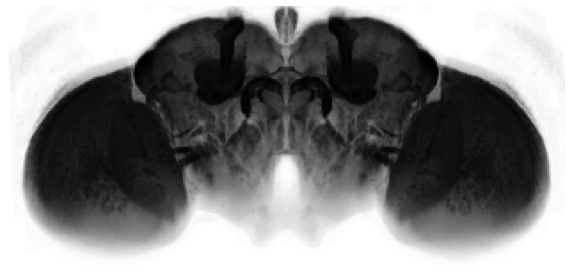

In [13]:
fig = plt.subplots(figsize=(10,10))
plt.imshow(np.max(fixed.numpy(), axis=-1).T, cmap='binary')
plt.axis('off');
# plt.savefig(os.path.join(save_dir,'fda_mean_brain.png'), dpi=300, bbox_inches='tight')

In [14]:
behave_dict_g['total'].shape

(314, 146, 91, 24)

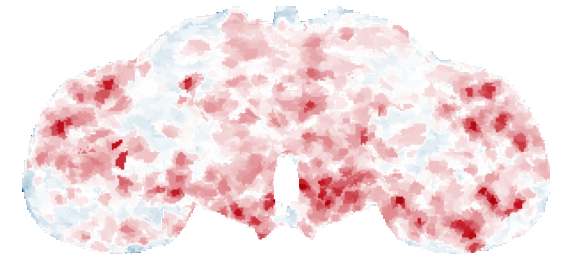

In [15]:
color_map_color_1=np.asarray(['#780000','#C1121F','#E0898F','#F0C4C7','#FFFFFF','#D9E6EF','#B3CDDE','#669BBC', '#003049'])[::-1]

color_map_color_2=np.asarray(['#5005AF','#9D69D4','#CCB2E7','#FBFAFA','#F6C0DC','#F186BE', '#DB0066' ])

color_map_color_3=np.asarray(['#054A29','#6BAB90','#B5D5C8','#FFFFFF','#E4C5DC','#C98BB9', '#7D5BA6' ])

color_map_color_4=np.asarray(['#1F2041','#4B3F72','#A59FB9','#D2CFDC','#FFFFFF','#C4E7E9','#88CED2','#119DA4', '#19647E' ])

total_colors=color_map_color_3

cmap_personal = matplotlib.colors.LinearSegmentedColormap.from_list(
    'cmap', color_map_color_1)

# cmap=matplotlib.colors.ListedColormap(total_colors)
fig, axs = plt.subplots(figsize=(10,10))
# img=axs.imshow(np.nanmean(np.nanmax(masked[25:30,...], axis=-1), axis=0).T, cmap='Spectral')
img=axs.imshow(np.nanmax(masked[...,10], axis=-1).T, cmap=cmap_personal)
axs.axis('off');
# fig.colorbar(img, ax=axs)
# plt.savefig(os.path.join(save_dir,'STA.png'), dpi=300, bbox_inches='tight')

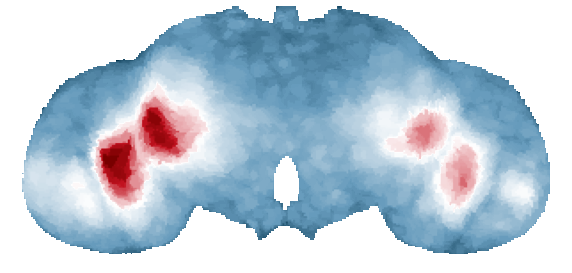

In [16]:
fig, axs = plt.subplots(figsize=(10,10))
# axs.imshow(np.nanmean(np.nanmax(masked[70:85,...], axis=-1), axis=0).T, cmap='Spectral_r')
img=axs.imshow(np.nanmax(masked[...,15], axis=-1).T, cmap=cmap_personal)
axs.axis('off');
# fig.colorbar(img, ax=axs)

In [17]:
vox_traces=masked
# vox_traces_pre=masked[25]
# vox_traces_post=masked[75]
vox_traces_pre=masked[...,2]
vox_traces_post=masked[...,15]
print(vox_traces.shape)
# z,xy,t=vox_traces.shape
# t,x,y,z=vox_traces.shape
x,y,z,t=vox_traces.shape
flattened=vox_traces.reshape(x*y*z*t)
flattened_pre=vox_traces_pre.reshape(x*y*z)
flattened_pre=flattened_pre[~np.isnan(flattened_pre)]
flattened_post=vox_traces_post.reshape(x*y*z)
flattened_post=flattened_post[~np.isnan(flattened_post)]
print(flattened.shape)

(314, 146, 91, 24)
(100123296,)


In [18]:
def mean_edges(flattened):
    mean_line=np.nanmean(flattened)
    std=np.nanstd(flattened)
    neg_edge=mean_line-std
    pos_edge=mean_line+std
    return mean_line, neg_edge, pos_edge

In [19]:
m,n,p=mean_edges(flattened)
mr,nr,pr=mean_edges(flattened_pre)
mo,no,po=mean_edges(flattened_post)

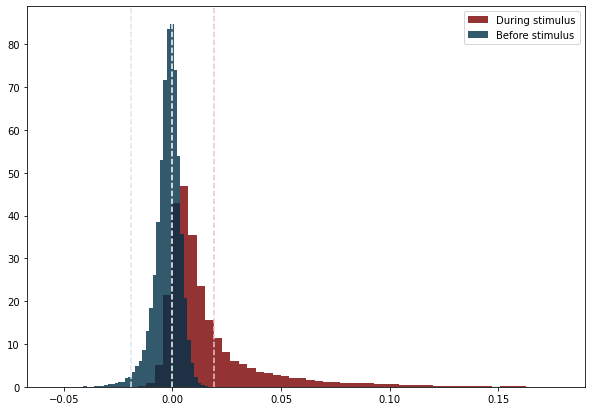

In [20]:
n_bins=100
fig, ax=plt.subplots(figsize=(10,7));
# plt.hist(flattened, bins=n_bins, density=True, color='k', label="Total");
ax.hist(flattened_post, bins=int(n_bins/2), density=True,color='#780000', alpha=0.8, label="During stimulus");
ax.hist(flattened_pre, bins=int(n_bins/2), density=True, color='#003049', alpha=0.8, label="Before stimulus");


ax.axvline(m, ls='--', color='w')
ax.axvline(n*2, ls='--', color='#D9E6EF')
ax.axvline(p*2, ls='--', color='#F0C4C7')
# ax.set_xlim((-0.1,0.2))
ax.legend();
# plt.savefig(os.path.join(save_dir,'supervox_hist.png'), dpi=300, bbox_inches='tight')
# plt.savefig(os.path.join(save_dir,'supervox_hist.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)

In [21]:
hist_b, edges_b=np.histogram(flattened_pre, bins=int(n_bins/2), density=True)
hist_d, edges_d=np.histogram(flattened_post, bins=int(n_bins/2), density=True)

In [22]:
edges_d.max()

0.17825527489185333

In [23]:
b=norm.cdf(hist_b, edges_b[:-1])
d=norm.cdf(hist_d, edges_d[:-1])
print(np.shape(b))

(50,)


In [24]:
Xb=flattened_pre.reshape(-1,1)
Xd=flattened_post.reshape(-1,1)
valb, edgesb=np.histogram(Xb)
vald, edgesd=np.histogram(Xd)
all_edges=[edgesb.max(), edgesb.min(), edgesd.max(), edgesd.min()]
total_max=np.max(all_edges)
total_min=np.min(all_edges)
x = np.linspace(total_min, total_max, 1000)

In [25]:
def make_cdf(X, x, comps):
    # estimate probability density function (pdf)
    model = GaussianMixture(n_components=comps)
    model.fit(X)
    logprob = model.score_samples(x.reshape(-1, 1))
    pdf = np.exp(logprob)
    # derive cumulative distribution function (cdf)
    cdf = np.cumsum(pdf)
    # scale as a probability distribution
    cdf = cdf / np.max(cdf)
    return cdf,pdf

In [26]:
cdfb, pdfb=make_cdf(Xb, x, 5)
cdfd, pdfd=make_cdf(Xd, x, 5)

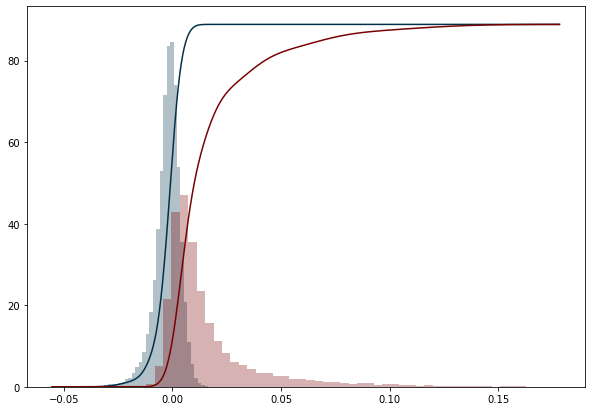

In [27]:
# plot data and pdf  
plt.subplots(figsize=(10,7));
plt.hist(Xb, 50, density=True,color='#003049', histtype='stepfilled', alpha=0.3)
plt.hist(Xd, 50, density=True,color='#780000', histtype='stepfilled', alpha=0.3)
# plt.plot(x, pdfb, '-k', alpha=0.3)
# plt.plot(x, pdfd, '-k', alpha=0.3)
# plot cdf, scaled to the y limits of the above plot
xmin, xmax, ymin, ymax = plt.axis()
plt.plot(x, cdfb * ymax, color='#003049', label="Before stimulus");
plt.plot(x, cdfd * ymax, color='#780000', label="During stimulus");
# plt.savefig(os.path.join(save_dir,'supervox_hist.png'), dpi=300, bbox_inches='tight')
# plt.legend();

In [28]:
KS = scipy.stats.ks_2samp(cdfb, cdfd)
MW = scipy.stats.mannwhitneyu(cdfb, cdfd)
TT = scipy.stats.ttest_ind(cdfb, cdfd)

In [29]:
print(KS)
print(MW)
print(TT)

KstestResult(statistic=0.683, pvalue=1.2648578104450944e-222)
MannwhitneyuResult(statistic=215565.5, pvalue=7.101934313837681e-111)
Ttest_indResult(statistic=4.265144864186253, pvalue=2.090938102425147e-05)


In [30]:
imgs = axs.get_images()
if len(imgs) > 0:
    vmin, vmax = imgs[0].get_clim()

In [31]:
vmax

0.17825527489185333

In [32]:
load_file = "/oak/stanford/groups/trc/data/Brezovec/2P_Imaging/anat_templates/20210817_luke_mean_highres.nii"
anat_high_res = np.asarray(nib.load(load_file).get_fdata().squeeze(), dtype='float32')
anat_high_res.shape

(1256, 584, 363)

In [33]:
atlas_path = "/oak/stanford/groups/trc/data/Brezovec/2P_Imaging/anat_templates/jfrc_2018_rois_improve_reorient_transformed_nearest_neighbor.nii"
atlas = np.asarray(nib.load(atlas_path).get_fdata().squeeze(), dtype='float32')
atlas = ants.from_numpy(atlas)
atlas.set_spacing((.76,.76,.76))
#atlas = ants.resample_image(atlas,(2,2,2),use_voxels=False)
atlas = ants.resample_image(atlas,(.5,.5,.5),use_voxels=False)
print(atlas.shape)
atlas = atlas.numpy()
atlas_int = atlas.astype('uint8')

(1256, 584, 363)


In [34]:
full_res_total_clean.shape

(314, 146, 91, 24)

In [35]:
%%time
# brain_pre=np.mean(full_res['total'][25:35,...], axis=0)
# brain_pre=full_res['total'][25,...]
# brain_pre=behave_dict['total'][...,2]
brain_pre=full_res['total'][...,2]
# brain_pre=np.nan_to_num(full_res_total_clean[...,2])
# brain_post=np.mean(full_res['total'][70:85,...], axis=0)
# brain_post=full_res['total'][75,...]
brain_post=full_res['total'][...,15]
# brain_post=np.nan_to_num(full_res_total_clean[...,15])
# brain_post=behave_dict['total'][...,14]
# plt.imshow(brain_pre[...,10])
# Calculate the scaling factors
nx,ny,nz=atlas.shape
ox,oy,oz=brain_pre.shape
scale_factors = (nx/ox, ny/oy, nz/oz)
# Resample using zoom with cubic interpolation (order=3)
maps_voxel_high_res_pre = zoom(brain_pre, scale_factors, order=3)
maps_voxel_high_res_post = zoom(brain_post, scale_factors, order=3)

CPU times: user 2min 1s, sys: 496 ms, total: 2min 1s
Wall time: 2min 1s


In [36]:
maps_voxel_high_res_post.shape

(1256, 584, 363)

In [37]:
no, nr, pr, po

(-0.006880530848525027,
 -0.008040695892706305,
 0.0036653120298452664,
 0.038780499387572984)

In [38]:
masked_pre=np.where(anat_high_res>0.1,maps_voxel_high_res_pre, np.nan)
masked_post=np.where(anat_high_res>0.1,maps_voxel_high_res_post, np.nan)

total_masked_pre_max=np.where(masked_pre>(p*2),masked_pre, np.nan)
total_masked_pre_min=np.where(masked_pre<(n*2),masked_pre, np.nan)
total_masked_post_max=np.where(masked_post>(p*2),masked_post, np.nan)
total_masked_post_min=np.where(masked_post<(n*2),masked_post, np.nan)

In [39]:
# Extract the top half of plasma_r colors
# spect_cmap = plt.cm.Spectral
# spect_cmap_r = plt.cm.Spectral_r
# top_half_colors = spect_cmap(np.linspace(0.5, 0.0, 256))  # Only use 0-0.5 range
# bottom_half_colors = spect_cmap_r(np.linspace(0.0, 0.5, 256)) 
# # Create a new colormap
# top_half_spect = matplotlib.colors.LinearSegmentedColormap.from_list(
#     'top_half_spect', top_half_colors)
# bottom_half_spect = matplotlib.colors.LinearSegmentedColormap.from_list(
#     'bottom_half_spect', bottom_half_colors)

top_color=np.asarray(['#780000','#C1121F','#E0898F','#F0C4C7'])[::-1]
bottom=np.asarray(['#D9E6EF','#B3CDDE','#669BBC', '#003049'])[::-1]
top_half_spect = matplotlib.colors.LinearSegmentedColormap.from_list(
    'top_half_spect', top_color)
bottom_half_spect = matplotlib.colors.LinearSegmentedColormap.from_list(
    'bottom_half_spect', bottom)


# Register the new colormap
plt.register_cmap(cmap=top_half_spect)
plt.register_cmap(cmap=bottom_half_spect)

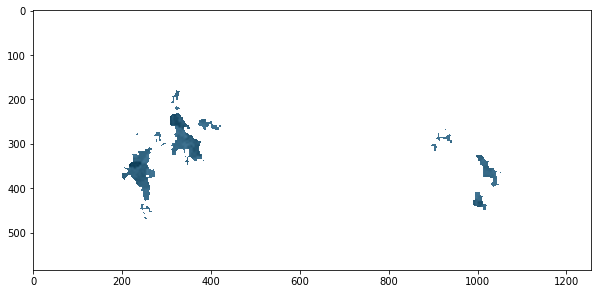

In [40]:
plt.figure(figsize=(10,10))
plt.imshow(total_masked_pre_min[...,200].T, vmax=0.05, cmap='bottom_half_spect')
# norm = matplotlib.colors.Normalize(vmin=-vmax, vmax=vmax)
# final = norm(final)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


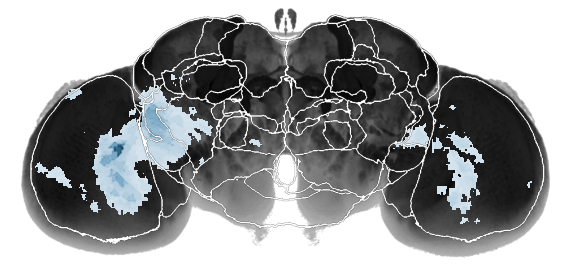

In [41]:
z=250
edges = cv2.Canny(np.max(atlas_int,axis=-1),1,1)
edges = binary_dilation(edges, iterations=1)
edges = scipy.ndimage.median_filter(edges,2)
edges_ = np.repeat(edges.astype('int')[:,:,np.newaxis],repeats=4,axis=-1) ### copy into rgba channels to make white
plt.figure(figsize=(10,10))
plt.imshow(np.max(anat_high_res, axis=-1).T,cmap='gray_r');
# plt.imshow(np.nanmax(total_masked_pre_max, axis=-1).T,vmax=0.05,cmap='top_half_spect');
plt.imshow(np.nanmin(total_masked_pre_min, axis=-1).T,cmap='bottom_half_spect');
plt.imshow(np.swapaxes(edges_,0,1)*10000);
plt.axis('off');
# plt.savefig(os.path.join(save_dir,f'total_overlay_15_min.png'), dpi=300, bbox_inches='tight')

In [ ]:
max_count=np.count_nonzero(~np.isnan(total_masked_post_max))
total_count=np.count_nonzero(~np.isnan(masked_post))
percent=(max_count/total_count)*100

In [ ]:
percent

In [ ]:
red_vals=np.where(masked_pre>p,masked_pre, np.nan)
red_count=np.count_nonzero(~np.isnan(red_vals))
total_count=np.count_nonzero(~np.isnan(masked_post))
percent_red=(red_count/total_count)*100

In [ ]:
percent_red

In [ ]:
roi_atlas = brainsss.load_roi_atlas()

In [ ]:
explosion_rois = brainsss.load_explosion_groups()
all_rois = brainsss.unnest_roi_groups(explosion_rois)
roi_masks = brainsss.make_single_roi_masks(all_rois, roi_atlas)
roi_contours = brainsss.make_single_roi_contours(roi_masks, roi_atlas)

In [ ]:
def extract_roi_signal_traces(roi_ids, roi_masks, warps, hemi, signal_type):
    t0 = time.time()
    roi_time_avgs = []
    for roi in roi_ids[hemi]:
        mask = roi_masks[roi]
        masked_data = warps[:,:,:,:]*mask[np.newaxis,:,:,:] #note z-flip
        if signal_type == 'max':
            roi_time_avg = np.max(masked_data,axis=(1,2,3))
        elif signal_type == 'mean':
            roi_time_avg = np.mean(masked_data,axis=(1,2,3))
        roi_time_avgs.append(roi_time_avg)
    print(time.time()-t0)
    return np.asarray(roi_time_avgs)

In [ ]:
# %%time
# brain=full_res['total']
# t=np.shape(brain)[0]
# explosions = []
# for tp in range(t):
#     input_canvas = np.ones((500,500,3)) #+.5 #.5 for diverging
#     data_to_plot = brain[tp][:,:,::-1]
#     vmax = 0.08 #this was 0.5 for STA <------------
#     explosion_map = brainsss.place_roi_groups_on_canvas(explosion_rois,
#                                                         roi_masks,
#                                                         roi_contours,
#                                                         data_to_plot,
#                                                         input_canvas,
#                                                         vmax=vmax,
#                                                         cmap='PuOr', diverging=True)#'hot')
#     explosions.append(explosion_map)

In [ ]:
brain=np.moveaxis(behave_dict['total'],-1,0)
# brain=np.moveaxis(np.nan_to_num(full_res_total_clean),-1,0)
input_canvas = np.ones((500,500,3)) #+.5 #.5 for diverging
data_to_plot = brain[15][:,:,::-1]
vmax = 0.05 #this was 0.5 for STA <------------
explosion_map = brainsss.place_roi_groups_on_canvas(explosion_rois,
                                                    roi_masks,
                                                    roi_contours,
                                                    data_to_plot,
                                                    input_canvas,
                                                    vmax=vmax,
                                                    cmap=cmap_personal, diverging=True)#'hot')

In [ ]:
save_dir=os.path.join(later_dir,'figs')
plt.subplots(figsize=(10,10))
# plt.imshow(explosions[40][170:,:]) #this was made with cmap=hot
plt.imshow(explosion_map[170:,:]) #this was made with cmap=hot
plt.axis('off')
# plt.savefig(os.path.join(save_dir,'explode_15.png'), dpi=300, bbox_inches='tight')

In [ ]:
os.listdir(later_dir)

In [ ]:
mx,mn=np.max(supervox_dict_total['total']),np.min(supervox_dict_total['total'])
print(mx,mn)

In [ ]:
be='total'
order=3
fs=1000/int(2500/np.shape(supervox_dict_total[be])[-1])
f0=2
b, a = butter(order, f0/(fs/2), btype='low', analog=False)
lowpass_dict={}
for behave in supervox_dict_total:
    lowpass = filtfilt(b, a, supervox_dict_total[behave], axis=-1)
    lowpass_dict[behave]=np.asarray(lowpass)

In [ ]:
np.shape(supervox_dict_total['total'])

In [ ]:
fig,axs = plt.subplots(figsize=(10,10))
axs.imshow(supervox_dict_total[be][50],cmap='magma',vmax=0.01, vmin=-0.01, interpolation='gaussian')
axs.set_yticks([])
axs.set_aspect(0.003)

In [ ]:
supervox_dict_total[be].shape

In [ ]:
fig,axs = plt.subplots();
axs.plot(supervox_dict_total[be][20].T,color='gray', alpha=0.03);
axs.plot(np.mean(supervox_dict_total[be][20],axis=0), color='k');
axs.set_ylim(-0.05,0.2);

fig,axs = plt.subplots();
axs.plot(supervox_dict_total[be][40].T,color='gray', alpha=0.03);
axs.plot(np.mean(supervox_dict_total[be][40],axis=0), color='k');
axs.set_ylim(-0.05,0.2);

fig,axs = plt.subplots();
axs.plot(supervox_dict_total[be][50].T,color='gray', alpha=0.03);
axs.plot(np.mean(supervox_dict_total[be][50],axis=0), color='k');
axs.set_ylim(-0.05,0.2);

fig,axs = plt.subplots();
axs.plot(supervox_dict_total[be][90].T,color='gray', alpha=0.03);
axs.plot(np.mean(supervox_dict_total[be][90],axis=0), color='k');
axs.set_ylim(-0.05,0.2);

In [ ]:
np.moveaxis(supervox_total_clean,1,-1).shape

In [ ]:
# data=gaussian_filter(supervox_dict_total[be], sigma=0.5)
data=supervox_dict_total[be]
# data=np.moveaxis(supervox_total_clean,1,-1)
vmax=0.007
vmin=-0.007
# norm = matplotlib.colors.Normalize(vmin=-vmax, vmax=vmax)
# final = norm(data)
# mycmap = matplotlib.cm.get_cmap('magma')
# final = mycmap(final)
num_areas=np.shape(data)[0]
fig = plt.figure(figsize=(10,30))
gs = fig.add_gridspec(nrows=num_areas, ncols=1, hspace=0)
axs = gs.subplots(sharex='col', sharey=False)
for i in range(num_areas):
    img=axs[i].imshow(data[i], cmap='magma', vmax=vmax, vmin=vmin, interpolation='gaussian')
    axs[i].set_yticks([])
    #     axs[i].set_xticks([])
    axs[i].set_aspect(0.0004)
    axs[i].axvline(x=6, ymin=0, ymax=1, ls='--', color='w', lw=2)
    axs[i].axvline(x=16, ymin=0, ymax=1, ls='--', color='w', lw=2)
#     axs[i].set_ylabel(f'z={i}', rotation=0, labelpad=20)
for ax in axs:
    ax.label_outer()
    ax.spines['top'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)
# fig.colorbar(img, ax=axs)

# plt.savefig(os.path.join(save_dir,'supervox_heatmap.png'), dpi=150)
# plt.savefig(os.path.join(save_dir,'supervox_heatmap.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)

plt.show()

In [ ]:
np.mean(brain[:,:,15])/np.abs(np.mean(brain[:,:,2]))

In [ ]:
z,xy,t=brain.shape
flat_brain=brain.reshape(z*xy,t)
print(np.shape(flat_brain))

count_more=0
for vox in flat_brain:
    if vox[2]<vox[15] or vox[2]<vox[14]:
        count_more+=1
print(count_more/(z*xy))

In [ ]:
# data=os.path.join(later_dir,'individual_supervox_dict.h5')

# with open(data, 'rb') as file:
#     loaded_data = pickle.load(file)

In [ ]:
# np.shape(loaded_data['250'])

In [ ]:
# avgs=[]
# bad_flies=['208','209','210','217','218','233']
# for key in loaded_data:
#     if key not in bad_flies:
#         print(key)
#         temp = np.asarray(loaded_data[key])[...,:1024]
#         mean = np.nanmean(temp, axis=(0,1))
#         avgs.append(mean)

In [ ]:
# avgs=np.asarray(avgs)
# print(avgs.shape)
# total_avg=np.nanmean(avgs,axis=0)
# print(total_avg.shape)

In [ ]:
# total_avg

In [ ]:
# ts_w_dir='/oak/stanford/groups/trc/data/Ilana/2P/data/fly_250/temp_filter/ts_rel_odd_mask_total.h5'
# with h5py.File(ts_w_dir, 'r') as tf:
#     ts_w = tf['ts_rel'][:]
#     print(np.shape(ts_w))

In [ ]:
# fig, axs=plt.subplots(figsize=(15,10))

# axs.plot(avgs.T, color='gray', alpha=0.3);
# axs.plot(total_avg, color='k', lw=4)
# axs.set_ylim(-0.02,0.03);
# # axs.axvline(160,color='k',linestyle='--',lw=2)
# # axs.axvline(60,color='k',linestyle='--',lw=2)